In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from functions import concatenate_actions, plot_compnorm_lc, plot_lightcurve, comp_norm
from glob import glob
import os
import numpy as np

%matplotlib widget

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from functions import concatenate_actions, plot_compnorm_lc, plot_lightcurve, comp_norm
from glob import glob
import os
import numpy as np

field_name = 'NG0301-3056'
campaign_name = '81120180822062757'
obj = '2018hib'


In [3]:
#actions = glob(f'images/{field_name}/{campaign_name}/action*/', recursive=True)
#full_df = concatenate_actions(actions, field_name, campaign_name)


58401.86799768519


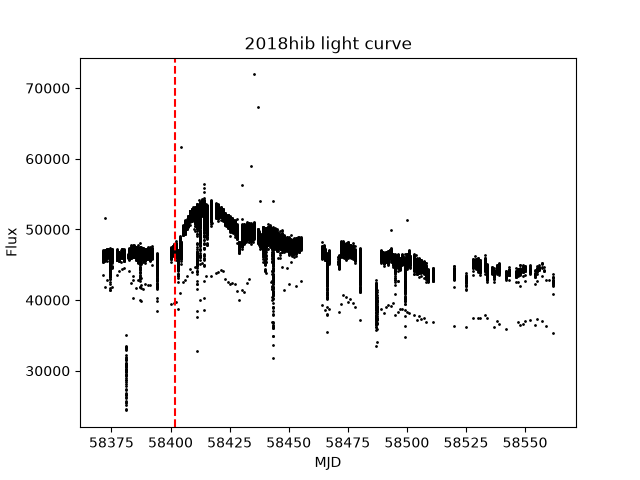

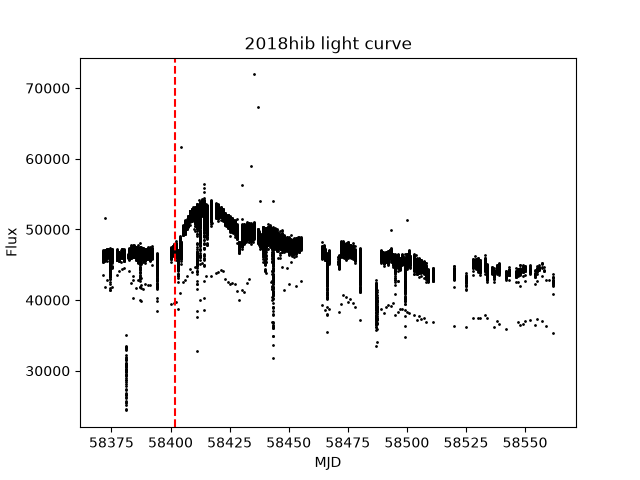

Number of comparison stars surviving the cut: 148
148
magnitude of added comparison stars = 5.615


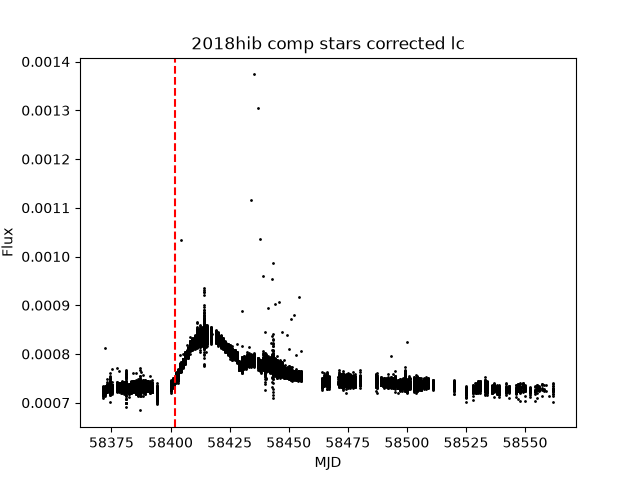

28716
58401.86799768519
0        58371.245422
1        58371.246753
2        58371.250093
3        58371.253495
4        58371.258530
             ...     
28711    58562.011672
28712    58562.012569
28713    58562.014282
28714    58562.014959
28715    58562.015475
Name: MJD, Length: 28716, dtype: float64
28716
28716


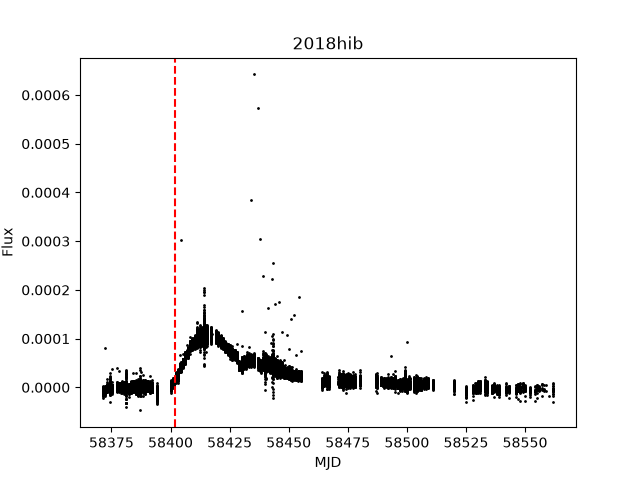

In [4]:
df = pd.read_csv('/scratch2/deasymic/NGTS/results/NG0301-3056/81120180822062757/NG0301-3056_81120180822062757_full.csv')
#df = full_df 
mjd = df['MJD']
flux_data = df[f'{obj}_flux']

df_fields_obs = pd.read_csv('fields_and_observing_times_corrected.csv')
comp_df = pd.read_csv(f'field_info/{field_name}/{field_name}_comparison_stars.csv')

row = df_fields_obs[(df_fields_obs['field_name'] == field_name)]
start_mjd = row['start_time (mjd)'].values[0]
disc_mag = 15.89
disc_mjd = start_mjd + 30
print(disc_mjd)


fig, ax = plt.subplots()
ax.scatter(mjd, flux_data, s=1, color='black')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(f'{obj} light curve')
#ax.set_ylim(0, 5000)
plt.show()

fig, ax = plt.subplots()
ax.scatter(mjd, flux_data, s=1, color='black')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(f'{obj} light curve')
#ax.set_ylim(0, 5000)
#ax.set_xlim(58090, 58190)
plt.show()

obj_flag = df[f'{obj}_flag']
obj_flux = df[f'{obj}_flux']
obj_fluxerr = df[f'{obj}_flux_err']

source_ids = comp_df['source_id']
rms_norm_fluxes = np.zeros(len(source_ids))
for i in range(len(source_ids)):
    source_id = source_ids[i]

    flux = df[f'{source_id}_flux']
    med_norm_flux = flux / np.median(flux)
    rms_norm_flux = np.sqrt(np.mean((med_norm_flux - 1) ** 2))
    rms_norm_fluxes[i] = rms_norm_flux

    if i == 0:
        comp = df[f'{source_id}_flux'].to_numpy()
        comp_err = df[f'{source_id}_flux_err'].to_numpy()
        comp_flag = df[f'{source_id}_flag'].to_numpy()
       
    else:
        comp = np.vstack((comp, df[f'{source_id}_flux'].to_numpy()))
        comp_err = np.vstack((comp_err, df[f'{source_id}_flux_err'].to_numpy()))
        comp_flag = np.vstack((comp_flag, df[f'{source_id}_flag'].to_numpy()))

percentile_cut = np.nanpercentile(rms_norm_fluxes, 84)
flag_bool = comp_flag != 0
flag_frac = np.count_nonzero(flag_bool, axis=1) / comp_flag.shape[1]
comp_mask = (rms_norm_fluxes < percentile_cut) & (flag_frac < 0.01)

good_comp = comp[comp_mask]
good_comp_err = comp_err[comp_mask]
good_comp_flag = comp_flag[comp_mask]
#good_comp_mag = comp_mag[comp_mask]
print(f"Number of comparison stars surviving the cut: {np.count_nonzero(comp_mask)}")

g_mag = comp_df['phot_g_mean_mag'][comp_mask]
print(len(g_mag))

linear_brightness = 10**(-0.4 * g_mag)
added_brightness = np.sum(linear_brightness)

mag_added = -2.5 * np.log10(added_brightness)
print(f'magnitude of added comparison stars = {mag_added:.3f}')

master_comp = np.sum(good_comp, axis=0)
master_comp_err = np.sqrt(np.sum(good_comp_err ** 2, axis=0))
master_comp_flag = np.sum(good_comp_flag, axis=0)


flag_mask = (obj_flag == 0)
corrected_flux = obj_flux[flag_mask] / master_comp[flag_mask]
corrected_flux_err = obj_fluxerr[flag_mask] / master_comp[flag_mask]
mjd = mjd[flag_mask]

#make other plot here
fig, ax = plt.subplots()
ax.scatter(mjd, corrected_flux, s=1, color='black')
ax.set_title(f'{obj} comp stars corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
#ax.set_ylim(0, 0.00005)
plt.show()

print(len(mjd))
print(disc_mjd)
print(mjd)
print(len(mjd<disc_mjd))
print(len(corrected_flux))

'''
sn_mag =-2.5*np.log10(corrected_flux) + mag_added
disc_mag=15.89

fig, ax = plt.subplots()
ax.scatter(mjd, sn_mag, s=1, color='black')
ax.set_title(f'{obj} comp stars corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Magnitude')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
plt.axhline(disc_mag, color='blue', linestyle='--', label='Discovery Mag')
ax.set_ylim(17.5, 14.5)
ax.legend()
plt.show()

'''


med_flux = np.median(corrected_flux[mjd < disc_mjd])
#med_flux = np.median(corrected_flux[mjd > 58050])
corrected_flux -= med_flux
#corrected_flux_err -= med_flux

fig, ax = plt.subplots()
ax.scatter(mjd, corrected_flux, s=1, color='black')
ax.set_title(f'{obj} comp star corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
#ax.set_ylim(0, 2.5)
#ax.set_xlim(58090, 58190)
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(obj)
plt.show()


58401.86799768519


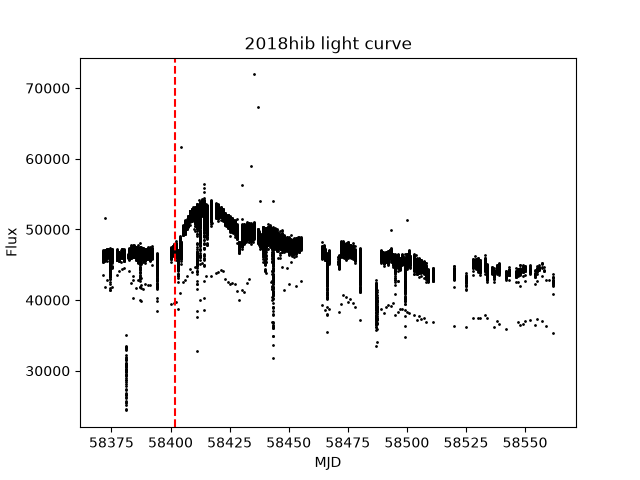

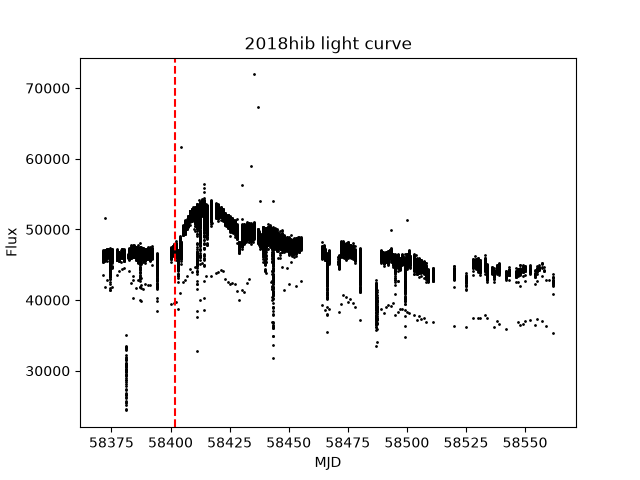

Number of comparison stars surviving the cut: 148
148
magnitude of added comparison stars = 5.615


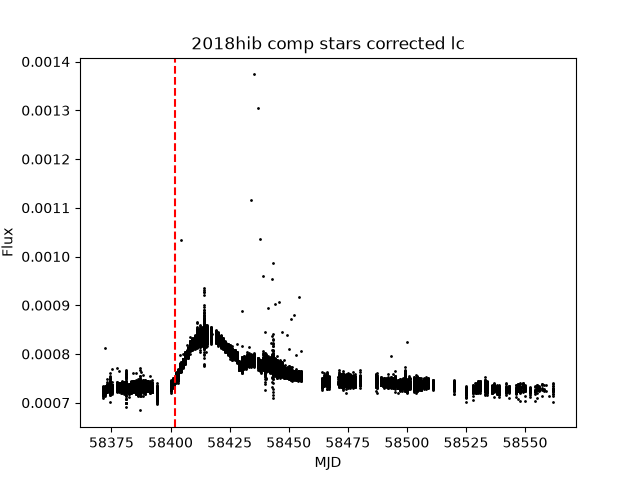

28716
58401.86799768519
0        58371.245422
1        58371.246753
2        58371.250093
3        58371.253495
4        58371.258530
             ...     
28711    58562.011672
28712    58562.012569
28713    58562.014282
28714    58562.014959
28715    58562.015475
Name: MJD, Length: 28716, dtype: float64
28716
28716


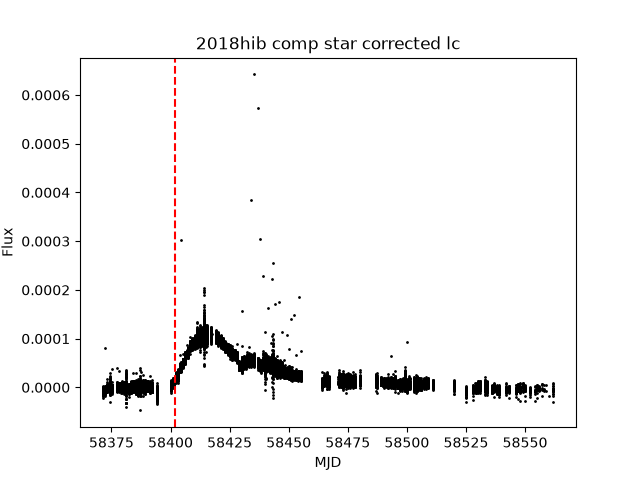

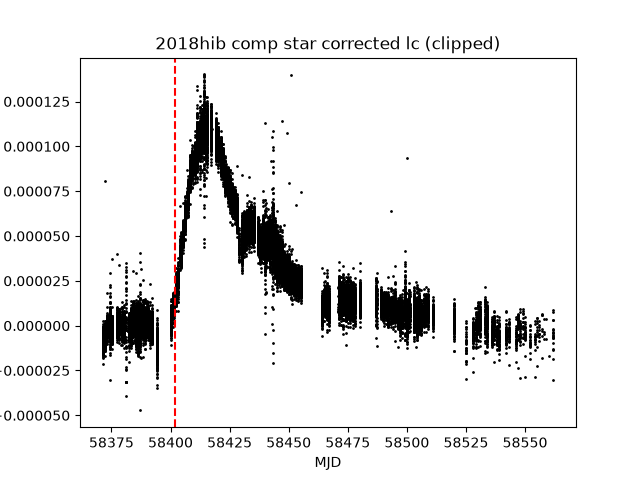

In [ ]:

#df = full_df 
mjd = df['MJD']
flux_data = df[f'{obj}_flux']

df_fields_obs = pd.read_csv('fields_and_observing_times_corrected.csv')
comp_df = pd.read_csv(f'field_info/{field_name}/{field_name}_comparison_stars.csv')

row = df_fields_obs[(df_fields_obs['field_name'] == field_name)]
start_mjd = row['start_time (mjd)'].values[0]
disc_mag = 15.89
disc_mjd = start_mjd + 30
print(disc_mjd)


fig, ax = plt.subplots()
ax.scatter(mjd, flux_data, s=1, color='black')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(f'{obj} light curve')
#ax.set_ylim(0, 5000)
plt.show()

fig, ax = plt.subplots()
ax.scatter(mjd, flux_data, s=1, color='black')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(f'{obj} light curve')
#ax.set_ylim(0, 5000)
#ax.set_xlim(58090, 58190)
plt.show()

obj_flag = df[f'{obj}_flag']
obj_flux = df[f'{obj}_flux']
obj_fluxerr = df[f'{obj}_flux_err']

source_ids = comp_df['source_id']
rms_norm_fluxes = np.zeros(len(source_ids))
for i in range(len(source_ids)):
    source_id = source_ids[i]

    flux = df[f'{source_id}_flux']
    med_norm_flux = flux / np.median(flux)
    rms_norm_flux = np.sqrt(np.mean((med_norm_flux - 1) ** 2))
    rms_norm_fluxes[i] = rms_norm_flux

    if i == 0:
        comp = df[f'{source_id}_flux'].to_numpy()
        comp_err = df[f'{source_id}_flux_err'].to_numpy()
        comp_flag = df[f'{source_id}_flag'].to_numpy()
       
    else:
        comp = np.vstack((comp, df[f'{source_id}_flux'].to_numpy()))
        comp_err = np.vstack((comp_err, df[f'{source_id}_flux_err'].to_numpy()))
        comp_flag = np.vstack((comp_flag, df[f'{source_id}_flag'].to_numpy()))

percentile_cut = np.nanpercentile(rms_norm_fluxes, 84)
flag_bool = comp_flag != 0
flag_frac = np.count_nonzero(flag_bool, axis=1) / comp_flag.shape[1]
comp_mask = (rms_norm_fluxes < percentile_cut) & (flag_frac < 0.01)

good_comp = comp[comp_mask]
good_comp_err = comp_err[comp_mask]
good_comp_flag = comp_flag[comp_mask]
#good_comp_mag = comp_mag[comp_mask]
print(f"Number of comparison stars surviving the cut: {np.count_nonzero(comp_mask)}")

g_mag = comp_df['phot_g_mean_mag'][comp_mask]
print(len(g_mag))

linear_brightness = 10**(-0.4 * g_mag)
added_brightness = np.sum(linear_brightness)

mag_added = -2.5 * np.log10(added_brightness)
print(f'magnitude of added comparison stars = {mag_added:.3f}')

master_comp = np.sum(good_comp, axis=0)
master_comp_err = np.sqrt(np.sum(good_comp_err ** 2, axis=0))
master_comp_flag = np.sum(good_comp_flag, axis=0)


flag_mask = (obj_flag == 0)
corrected_flux = obj_flux[flag_mask] / master_comp[flag_mask]
corrected_flux_err = obj_fluxerr[flag_mask] / master_comp[flag_mask]
mjd = mjd[flag_mask]

#make other plot here
fig, ax = plt.subplots()
ax.scatter(mjd, corrected_flux, s=1, color='black')
ax.set_title(f'{obj} comp stars corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
#ax.set_ylim(0, 0.00005)
plt.show()

print(len(mjd))
print(disc_mjd)
print(mjd)
print(len(mjd<disc_mjd))
print(len(corrected_flux))

'''
sn_mag =-2.5*np.log10(corrected_flux) + mag_added
disc_mag=15.89

fig, ax = plt.subplots()
ax.scatter(mjd, sn_mag, s=1, color='black')
ax.set_title(f'{obj} comp stars corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Magnitude')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
plt.axhline(disc_mag, color='blue', linestyle='--', label='Discovery Mag')
ax.set_ylim(17.5, 14.5)
ax.legend()
plt.show()

'''


med_flux = np.median(corrected_flux[mjd < disc_mjd])
#med_flux = np.median(corrected_flux[mjd > 58050])
corrected_flux -= med_flux
#corrected_flux_err /= med_flux

fig, ax = plt.subplots()
ax.scatter(mjd, corrected_flux, s=1, color='black')
ax.set_title(f'{obj} comp star corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
#ax.set_ylim(0, 2.5)
#ax.set_xlim(58500, 58700)
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
plt.show()

#clipping 
mean_flux, std_flux = np.mean(corrected_flux), np.std(corrected_flux)
clip_mask = np.abs(corrected_flux - mean_flux) < 3 * std_flux
clipped_mjd = mjd[clip_mask]
clipped_flux = corrected_flux[clip_mask]
clipped_flux_err = corrected_flux_err[clip_mask]

fig, ax = plt.subplots()
ax.scatter(clipped_mjd, clipped_flux, s=1, color='black')
ax.set_title(f'{obj} comp star corrected lc (clipped)')
ax.set_xlabel('MJD')import pandas as pd
import matplotlib.pyplot as plt
from functions import concatenate_actions, plot_compnorm_lc, plot_lightcurve, comp_norm
from glob import glob
import os
import numpy as np
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
#ax.set_xlim(58500, 58700)
plt.show()  


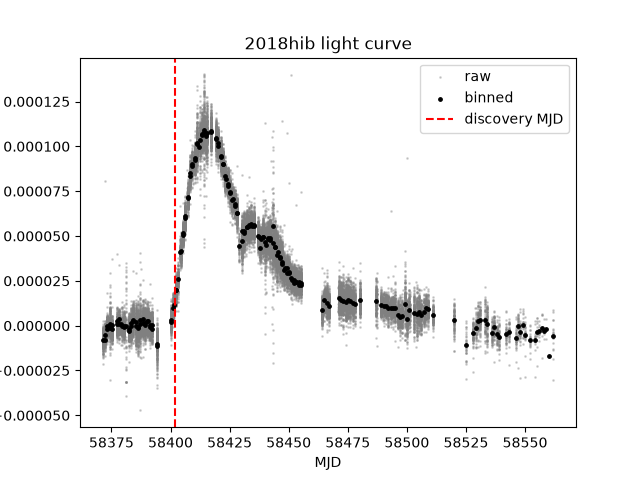

In [8]:
hr_bin = 6
bin_width = hr_bin/24  
bins = np.arange(clipped_mjd.min(), clipped_mjd.max() + bin_width, bin_width)
bin_idx = np.digitize(clipped_mjd, bins)

binned_time = np.array([clipped_mjd[bin_idx == i].mean() for i in np.unique(bin_idx)])
binned_flux = np.array([clipped_flux[bin_idx == i].mean() for i in np.unique(bin_idx)])
binned_err = np.array([clipped_flux_err[bin_idx == i].mean()/np.count_nonzero(bin_idx==i) for i in np.unique(bin_idx)])


fig, ax = plt.subplots()
ax.scatter(clipped_mjd, clipped_flux, s=1, label='raw', color='grey', alpha =0.3)
ax.scatter(binned_time, binned_flux, s=6, color='black', label='binned')
#ax.errorbar(binned_time, binned_flux, yerr=binned_err, ls='', capsize=2, marker='o', color='black', label=f'binned ({hr_bin} hr)', ms=3.5)
ax.set_title(f'{obj} light curve')
ax.set_xlabel('MJD')
ax.set_ylabel('Median normalised flux')
#ax.set_ylim(0, 2.5)
#ax.set_xlim(58525, 58700)
plt.axvline(disc_mjd, color='red', linestyle='--', label='discovery MJD')
ax.legend()
plt.show()


In [7]:


full_field = pd.concat([camp1, camp2], ignore_index=True)

campaign_name = '80920170822031123'

mjdc1 = camp2['MJD']
flux_datac1 = camp2[f'{obj}_flux']

df_fields_obs = pd.read_csv('fields_and_observing_times_corrected.csv')
comp_df = pd.read_csv(f'field_info/{field_name}/{field_name}_comparison_stars.csv')

row = df_fields_obs[(df_fields_obs['field_name'] == field_name)]
start_mjd = row['start_time (mjd)'].values[0]
disc_mjd = start_mjd + 30
print(disc_mjd)


fig, ax = plt.subplots()
ax.scatter(mjdc1, flux_datac1, s=1, color='black')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(f'{obj} light curve')
ax.set_ylim(0, 20000)
plt.show()

fig, ax = plt.subplots()
ax.scatter(mjdc1, flux_datac1, s=1, color='black')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(f'{obj} light curve')
ax.set_ylim(0, 20000)
#ax.set_xlim(58090, 58190)
plt.show()

obj_flag = camp2[f'{obj}_flag']
obj_flux = camp2[f'{obj}_flux']
obj_fluxerr = camp2[f'{obj}_flux_err']

source_ids = comp_df['source_id']
rms_norm_fluxes = np.zeros(len(source_ids))
for i in range(len(source_ids)):
    source_id = source_ids[i]

    flux = camp2[f'{source_id}_flux']
    med_norm_flux = flux / np.median(flux)
    rms_norm_flux = np.sqrt(np.mean((med_norm_flux - 1) ** 2))
    rms_norm_fluxes[i] = rms_norm_flux
    if i == 0:
        comp = camp2[f'{source_id}_flux'].to_numpy()
        comp_err = camp2[f'{source_id}_flux_err'].to_numpy()
        comp_flag = camp2[f'{source_id}_flag'].to_numpy()
    else:
        comp = np.vstack((comp, camp2[f'{source_id}_flux'].to_numpy()))
        comp_err = np.vstack((comp_err, camp2[f'{source_id}_flux_err'].to_numpy()))
        comp_flag = np.vstack((comp_flag, camp2[f'{source_id}_flag'].to_numpy()))

percentile_cut = np.nanpercentile(rms_norm_fluxes, 84)
flag_bool = comp_flag != 0
flag_frac = np.count_nonzero(flag_bool, axis=1) / comp_flag.shape[1]
comp_mask = (rms_norm_fluxes < percentile_cut) & (flag_frac < 0.01)

good_comp = comp[comp_mask]
good_comp_err = comp_err[comp_mask]
good_comp_flag = comp_flag[comp_mask]
print(f"Number of comparison stars surviving the cut: {np.count_nonzero(comp_mask)}")


g_mag = comp_df['phot_g_mean_mag'][comp_mask]
print(len(g_mag))

linear_brightness = 10**(-0.4 * g_mag)
added_brightness = np.sum(linear_brightness)

mag_added = -2.5 * np.log10(added_brightness)
print(f'magnitude of added comparison stars = {mag_added:.3f}')

master_comp = np.sum(good_comp, axis=0)
master_comp_err = np.sqrt(np.sum(good_comp_err ** 2, axis=0))
master_comp_flag = np.sum(good_comp_flag, axis=0)

flag_mask = (obj_flag == 0)
corrected_fluxc1 = obj_flux[flag_mask] / master_comp[flag_mask]
corrected_flux_errc1 = obj_fluxerr[flag_mask] / master_comp[flag_mask]
mjdc1 = mjdc1[flag_mask]

#make other plot here
fig, ax = plt.subplots()
ax.scatter(mjdc1, corrected_fluxc1, s=1, color='black')
ax.set_title(f'{obj} comp stars corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_ylim(0, 0.0003)
plt.show()

sn_magc1 =-2.5*np.log10(corrected_fluxc1) + mag_added
disc_mag=15.89

fig, ax = plt.subplots()
ax.scatter(mjdc1, sn_magc1, s=1, color='black')
ax.set_title(f'{obj} comp stars corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Magnitude')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
plt.axhline(disc_mag, color='blue', linestyle='--', label='Discovery Mag')
ax.set_ylim(17.5, 14.5)
ax.legend()
plt.show()



'''
med_fluxc1 = np.median(corrected_fluxc1[mjdc1 < disc_mjd])
#med_fluxc1 = np.median(corrected_flux[mjd > 58050])
corrected_fluxc1 /= med_fluxc1
corrected_flux_errc1 /= med_fluxc1camp1 = pd.read_csv('/scratch2/deasymic/NGTS/results/NG2158-3345/80920170423084403/NG2158-3345_80920170423084403_full.csv')
camp2 = pd.read_csv('/scratch2/deasymic/NGTS/results/NG2158-3345/80920170822031123/NG2158-3345_80920170822031123_full.csv')

fig, ax = plt.subplots()
ax.scatter(mjdc1, corrected_fluxc1, s=1, color='black')
ax.set_title(f'{obj} comp star corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
#ax.set_ylim(0, 8.5)
#ax.set_xlim(58090, 58190)
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(obj)
plt.show()
'''

NameError: name 'camp1' is not defined

In [ ]:
camp1 = pd.read_csv('/scratch2/deasymic/NGTS/results/NG2158-3345/80920170423084403/NG2158-3345_80920170423084403_full.csv')
camp2 = pd.read_csv('/scratch2/deasymic/NGTS/results/NG2158-3345/80920170822031123/NG2158-3345_80920170822031123_full.csv')

full_field = pd.concat([camp1, camp2], ignore_index=True)

#campaign_name = '80920170822031123'

mjd_full = full_field['MJD']
flux_data_full = full_field[f'{obj}_flux']

df_fields_obs = pd.read_csv('fields_and_observing_times_corrected.csv')
#comp_df = pd.read_csv(f'field_info/{field_name}/{field_name}_comparison_stars.csv')
comp_df = pd.read_csv('/scratch2/deasymic/NGTS/2017gah_discmag_compstars.csv')
row = df_fields_obs[(df_fields_obs['field_name'] == field_name)]
start_mjd = row['start_time (mjd)'].values[0]
disc_mjd = start_mjd + 30
print(disc_mjd)


fig, ax = plt.subplots()
ax.scatter(mjd_full, flux_data_full, s=1, color='black')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(f'{obj} bias and background subtracted light curve')
ax.set_ylim(0, 20000)
fig.savefig('2017gahbackgroundsubtractedlc_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

obj_flag = full_field[f'{obj}_flag']
obj_flux = full_field[f'{obj}_flux']
obj_fluxerr = full_field[f'{obj}_flux_err']

source_ids = comp_df['source_id']
rms_norm_fluxes = np.zeros(len(source_ids))
for i in range(len(source_ids)):
    source_id = source_ids[i]

    flux = full_field[f'{source_id}_flux']
    med_norm_flux = flux / np.median(flux)
    rms_norm_flux = np.sqrt(np.mean((med_norm_flux - 1) ** 2))
    rms_norm_fluxes[i] = rms_norm_flux
    if i == 0:
        comp = full_field[f'{source_id}_flux'].to_numpy()
        comp_err = full_field[f'{source_id}_flux_err'].to_numpy()
        comp_flag = full_field[f'{source_id}_flag'].to_numpy()
    else:
        comp = np.vstack((comp, full_field[f'{source_id}_flux'].to_numpy()))
        comp_err = np.vstack((comp_err, full_field[f'{source_id}_flux_err'].to_numpy()))
        comp_flag = np.vstack((comp_flag, full_field[f'{source_id}_flag'].to_numpy()))

percentile_cut = np.nanpercentile(rms_norm_fluxes, 84)
flag_bool = comp_flag != 0
flag_frac = np.count_nonzero(flag_bool, axis=1) / comp_flag.shape[1]
comp_mask = (rms_norm_fluxes < percentile_cut) & (flag_frac < 0.01)

good_comp = comp[comp_mask]
good_comp_err = comp_err[comp_mask]
good_comp_flag = comp_flag[comp_mask]
print(f"Number of comparison stars surviving the cut: {np.count_nonzero(comp_mask)}")


g_mag = comp_df['phot_g_mean_mag'][comp_mask]
print(len(g_mag))

linear_brightness = 10**(-0.4 * g_mag)
added_brightness = np.sum(linear_brightness)

mag_added = -2.5 * np.log10(added_brightness)
print(f'magnitude of added comparison stars = {mag_added:.3f}')

master_comp = np.sum(good_comp, axis=0)
master_comp_err = np.sqrt(np.sum(good_comp_err ** 2, axis=0))
master_comp_flag = np.sum(good_comp_flag, axis=0)

flag_mask = (obj_flag == 0)
corrected_flux_full = obj_flux[flag_mask] / master_comp[flag_mask]
corrected_flux_err_full = obj_fluxerr[flag_mask] / master_comp[flag_mask]
mjd_full = mjd_full[flag_mask]

#make other plot here
fig, ax = plt.subplots()
ax.scatter(mjd_full, corrected_flux_full, s=1, color='black')
ax.set_title(f'{obj} comparison stars corrected light curve')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_ylim(0, 0.0003)
fig.savefig('2017gahcompstarscorrectedlc_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

sn_mag_full =-2.5*np.log10(corrected_flux_full) + mag_added
disc_mag=15.89

fig, ax = plt.subplots()
ax.scatter(mjd_full, sn_mag_full, s=1, color='black')
ax.set_title(f'{obj} magnitude light curve')
ax.set_xlabel('MJD')
ax.set_ylabel('Magnitude')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
plt.axhline(disc_mag, color='blue', linestyle='--', label='Discovery Mag')
ax.set_ylim(17.5, 14.5)
ax.legend()
fig.savefig('2017gahcompstarscorrectedmaglc_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


med_flux_full = np.median(corrected_flux_full[mjd_full < disc_mjd])
#med_fluxc1 = np.median(corrected_flux[mjd > 58050])
#corrected_flux_full = corrected_flux_full-med_flux_full
#corrected_flux_err_full = corrected_flux_err_full-med_flux_full
corrected_flux_full /= med_flux_full
corrected_flux_err_full /= med_flux_full

fig, ax = plt.subplots()
ax.scatter(mjd_full, corrected_flux_full, s=1, color='black')
ax.set_title(f'{obj} median normalised light curve')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
ax.set_ylim(-0.5, 8)
#ax.set_xlim(58090, 58190)
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(obj)
fig.savefig('2017gahmediannormalisedlc_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

bin_width = 1/24  
bins = np.arange(mjd_full.min(), mjd_full.max() + bin_width, bin_width)
bin_idx = np.digitize(mjd_full, bins)

binned_time_full = np.array([mjd_full[bin_idx == i].mean() for i in np.unique(bin_idx)])
binned_flux_full = np.array([corrected_flux_full[bin_idx == i].mean() for i in np.unique(bin_idx)])
binned_err_full = np.array([corrected_flux_err_full[bin_idx == i].mean()/np.count_nonzero(bin_idx==i) for i in np.unique(bin_idx)])

fig, ax = plt.subplots()
ax.scatter(mjd_full, corrected_flux_full-1, s=1, label='raw', color='grey', alpha =0.3)
#ax.scatter(binned_time, binned_flux, s=6, color='black', label='binned')
ax.errorbar(binned_time_full, binned_flux_full-1, yerr=binned_err_full, ls='', capsize=2, marker='o', color='black', label='binned (1hr)', ms=3.5)
ax.set_title(f'{obj} light curve')
ax.set_xlabel('MJD')
ax.set_ylabel(f'{obj} binned median normalised light curve')
ax.set_ylim(-0.5, 4.5)
ax.set_xlim(57968, 57978)
plt.axvline(disc_mjd, color='red', linestyle='--', label='discovery MJD')
ax.legend()
fig.savefig('2017gahbinnedmediannormalisedlc_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


In [ ]:

fig, ax = plt.subplots()
ax.scatter(mjdc1, corrected_fluxc1, s=1, color='black')
ax.set_title(f'{obj} comp star corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(obj)
plt.show()


fig, ax = plt.subplots()
ax.scatter(mjd, corrected_flux, s=1, color='black')
ax.set_title(f'{obj} comp star corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(obj)
plt.show()

fig, ax = plt.subplots()
ax.scatter(mjd, corrected_flux, s=1, color='black')
ax.scatter(mjdc1, corrected_fluxc1, s=1, color='black')
ax.set_title(f'{obj} comp star corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(obj)
plt.show()

fig, ax = plt.subplots()
ax.scatter(mjdc1, corrected_fluxc1, s=1, color='black')
ax.scatter(mjd, corrected_flux, s=1, color='black')
ax.set_title(f'{obj} comp stars corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_ylim(0, 0.0003)
plt.show()


fig, ax = plt.subplots()
ax.scatter(mjd, sn_mag, s=1, color='black')
ax.scatter(mjdc1, sn_magc1, s=1, color='black')
ax.set_title(f'{obj} comp stars corrected lc')
ax.set_xlabel('MJD')
ax.set_ylabel('Magnitude')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
plt.axhline(disc_mag, color='blue', linestyle='--', label='Discovery Mag')
ax.set_ylim(17.5, 14.5)
ax.legend()
plt.show()



In [ ]:
#full_field = pd.read_csv('/scratch2/deasymic/NGTS/results/NG2051-3345/80220180319091620/NG2051-3345_80220180319091620_full.csv')
#full_field = pd.read_csv('/scratch2/deasymic/NGTS/results/NG2121-5148/80820170421084117/NG2121-5148_80820170421084117_full.csv')
full_field = pd.read_csv('/scratch2/deasymic/NGTS/results/NG1214-3922/80720171210080143/NG1214-3922_80720171210080143_full.csv')
#campaign_name = '80920170822031123'
#field_name = 'NG2051-3345'
#obj = '2018eod'

field_name = 'NG1214-3922'
obj = '2017jir'

mjd_full = full_field['MJD']
flux_data_full = full_field[f'{obj}_flux']

df_fields_obs = pd.read_csv('fields_and_observing_times_corrected.csv')
comp_df = pd.read_csv(f'/scratch2/deasymic/NGTS/field_info/NG1214-3922/NG1214-3922_comparison_stars.csv')

row = df_fields_obs[(df_fields_obs['field_name'] == field_name)]
start_mjd = row['start_time (mjd)'].values[0]
disc_mjd = start_mjd + 30
print(disc_mjd)


fig, ax = plt.subplots()
ax.scatter(mjd_full, flux_data_full, s=1, color='black')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(f'{obj} bias and background subtracted light curve')
#ax.set_ylim(0, 20000)
#fig.savefig('2017gahbackgroundsubtractedlc_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

obj_flag = full_field[f'{obj}_flag']
obj_flux = full_field[f'{obj}_flux']
obj_fluxerr = full_field[f'{obj}_flux_err']

source_ids = comp_df['source_id']
rms_norm_fluxes = np.zeros(len(source_ids))
for i in range(len(source_ids)):
    source_id = source_ids[i]

    flux = full_field[f'{source_id}_flux']
    med_norm_flux = flux / np.median(flux)
    rms_norm_flux = np.sqrt(np.mean((med_norm_flux - 1) ** 2))
    rms_norm_fluxes[i] = rms_norm_flux
    if i == 0:
        comp = full_field[f'{source_id}_flux'].to_numpy()
        comp_err = full_field[f'{source_id}_flux_err'].to_numpy()
        comp_flag = full_field[f'{source_id}_flag'].to_numpy()
    else:
        comp = np.vstack((comp, full_field[f'{source_id}_flux'].to_numpy()))
        comp_err = np.vstack((comp_err, full_field[f'{source_id}_flux_err'].to_numpy()))
        comp_flag = np.vstack((comp_flag, full_field[f'{source_id}_flag'].to_numpy()))

percentile_cut = np.nanpercentile(rms_norm_fluxes, 84)
flag_bool = comp_flag != 0
flag_frac = np.count_nonzero(flag_bool, axis=1) / comp_flag.shape[1]
comp_mask = (rms_norm_fluxes < percentile_cut) & (flag_frac < 0.01)

good_comp = comp[comp_mask]
good_comp_err = comp_err[comp_mask]
good_comp_flag = comp_flag[comp_mask]
print(f"Number of comparison stars surviving the cut: {np.count_nonzero(comp_mask)}")


g_mag = comp_df['phot_g_mean_mag'][comp_mask]
print(len(g_mag))

linear_brightness = 10**(-0.4 * g_mag)
added_brightness = np.sum(linear_brightness)

mag_added = -2.5 * np.log10(added_brightness)
print(f'magnitude of added comparison stars = {mag_added:.3f}')

master_comp = np.sum(good_comp, axis=0)
master_comp_err = np.sqrt(np.sum(good_comp_err ** 2, axis=0))
master_comp_flag = np.sum(good_comp_flag, axis=0)

flag_mask = (obj_flag == 0)
corrected_flux_full = obj_flux[flag_mask] / master_comp[flag_mask]
corrected_flux_err_full = obj_fluxerr[flag_mask] / master_comp[flag_mask]
mjd_full = mjd_full[flag_mask]

#make other plot here
fig, ax = plt.subplots()
ax.scatter(mjd_full, corrected_flux_full, s=1, color='black')
ax.set_title(f'{obj} comparison stars corrected light curve')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
#ax.set_ylim(0, 0.0003)
#fig.savefig('2017gahcompstarscorrectedlc_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

sn_mag_full =-2.5*np.log10(corrected_flux_full) + mag_added
disc_mag=15.89

fig, ax = plt.subplots()
ax.scatter(mjd_full, sn_mag_full, s=1, color='black')
ax.set_title(f'{obj} magnitude light curve')
ax.set_xlabel('MJD')
ax.set_ylabel('Magnitude')
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
plt.axhline(disc_mag, color='blue', linestyle='--', label='Discovery Mag')
#ax.set_ylim(17.5, 14.5)
ax.legend()
#fig.savefig('2017gahcompstarscorrectedmaglc_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()


med_flux_full = np.median(corrected_flux_full[mjd_full < disc_mjd])
#med_fluxc1 = np.median(corrected_flux[mjd > 58050])
corrected_flux_full /= med_flux_full
corrected_flux_err_full /= med_flux_full

fig, ax = plt.subplots()
ax.scatter(mjd_full, corrected_flux_full, s=1, color='black')
ax.set_title(f'{obj} median normalised light curve')
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
#ax.set_ylim(0, 8)
#ax.set_xlim(58090, 58190)
plt.axvline(disc_mjd, color='red', linestyle='--', label='Discovery MJD')
ax.set_title(obj)
#fig.savefig('2017gahmediannormalisedlc_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

bin_width = 1/24  
bins = np.arange(mjd_full.min(), mjd_full.max() + bin_width, bin_width)
bin_idx = np.digitize(mjd_full, bins)

binned_time_full = np.array([mjd_full[bin_idx == i].mean() for i in np.unique(bin_idx)])
binned_flux_full = np.array([corrected_flux_full[bin_idx == i].mean() for i in np.unique(bin_idx)])
binned_err_full = np.array([corrected_flux_err_full[bin_idx == i].mean()/np.count_nonzero(bin_idx==i) for i in np.unique(bin_idx)])

fig, ax = plt.subplots()
ax.scatter(mjd_full, corrected_flux_full, s=1, label='raw', color='grey', alpha =0.3)
#ax.scatter(binned_time, binned_flux, s=6, color='black', label='binned')
ax.errorbar(binned_time_full, binned_flux_full, yerr=binned_err_full, ls='', capsize=2, marker='o', color='black', label='binned (1hr)', ms=3.5)
ax.set_title(f'{obj} light curve')
ax.set_xlabel('MJD')
ax.set_ylabel(f'{obj} binned median normalised light curve')
#ax.set_ylim(0, 8.5)
#ax.set_xlim(58090, 58190)
plt.axvline(disc_mjd, color='red', linestyle='--', label='discovery MJD')
ax.legend()
#fig.savefig('2017gahbinnedmediannormalisedlc_transparent.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
